In [15]:
import os
import cv2
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

In [16]:
SEQUENCE_LENGTH = 16
BATCH_SIZE = 4
EPOCHS = 15
LR = 0.0005
NUM_WORKERS = 2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_SAVE_PATH = "densenet121_lstm_best.pth"

device = torch.device(DEVICE)
print(f"Using device: {device}")
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))


Using device: cuda
Tesla T4


In [17]:
DATA_ROOT = "/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/"

for d in os.listdir(DATA_ROOT):
    candidate = os.path.join(DATA_ROOT, d)
    if os.path.isdir(candidate) and "data" in os.listdir(candidate):
        DATA_ROOT = candidate
        break

TRAIN_CSV = os.path.join(DATA_ROOT, "data/train.csv")
TEST_CSV = os.path.join(DATA_ROOT, "data/test.csv")

def fix_path(p):
    return p.replace("\\", "/")

def prepare_csv(csv_path):
    df = pd.read_csv(csv_path)
    df["video_name"] = DATA_ROOT + "/" + df["video_name"].apply(fix_path)
    return df

train_df = prepare_csv(TRAIN_CSV)
test_df = prepare_csv(TEST_CSV)

print(len(train_df), len(test_df))


1520 380


In [18]:
classes = sorted(train_df["label"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
num_classes = len(classes)

print(class_to_idx)


{'abuse': 0, 'arrest': 1, 'arson': 2, 'assault': 3, 'burglary': 4, 'explosion': 5, 'fighting': 6, 'normal': 7, 'roadaccidents': 8, 'robbery': 9, 'shooting': 10, 'shoplifting': 11, 'stealing': 12, 'vandalism': 13}


In [19]:
class CSVVideoDataset(Dataset):
    def __init__(self, dataframe, sequence_length, transform, class_to_idx):
        self.df = dataframe
        self.sequence_length = sequence_length
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def _sample_frames(self, video_path):
        cap = cv2.VideoCapture(video_path)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        indices = np.linspace(0, frame_count - 1, self.sequence_length).astype(int)
        frames = []

        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret:
                frame = frames[-1] if frames else np.zeros((224,224,3), dtype=np.uint8)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

        cap.release()
        return frames

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frames = self._sample_frames(row["video_name"])
        frames = [self.transform(f) for f in frames]
        return torch.stack(frames), self.class_to_idx[row["label"]]


In [20]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

train_loader = DataLoader(
    CSVVideoDataset(train_df, SEQUENCE_LENGTH, transform, class_to_idx),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    CSVVideoDataset(test_df, SEQUENCE_LENGTH, transform, class_to_idx),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)


In [21]:
def compute_class_weights(df, class_to_idx):
    counts = Counter(df["label"])
    total = sum(counts.values())
    weights = [total / (len(class_to_idx) * counts[c]) for c in class_to_idx]
    return torch.tensor(weights, dtype=torch.float)

class_weights = compute_class_weights(train_df, class_to_idx).to(DEVICE)


In [22]:
class DenseNet121LSTM(nn.Module):
    def __init__(self, num_classes, hidden_size=256):
        super().__init__()

        backbone = models.densenet121(weights="IMAGENET1K_V1")

        self.feature_extractor = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))

        for param in list(self.feature_extractor.parameters())[:6]:
            param.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=1024,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)

        f = self.feature_extractor(x)
        f = self.pool(f)
        f = f.view(B, T, -1)

        _, (h_n, _) = self.lstm(f)
        return self.fc(h_n[-1])


In [23]:
model = DenseNet121LSTM(num_classes).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)


In [24]:
def train_model(model):
    best_acc = 0.0

    for epoch in range(EPOCHS):
        model.train()
        correct, total = 0, 0

        for x,y in train_loader:
            x,y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out,y)
            loss.backward()
            optimizer.step()

            correct += (out.argmax(1)==y).sum().item()
            total += y.size(0)

        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(DEVICE), y.to(DEVICE)
                out = model(x)
                val_correct += (out.argmax(1)==y).sum().item()
                val_total += y.size(0)

        acc = val_correct / val_total
        print(f"Epoch {epoch+1}/{EPOCHS} | Val Acc: {acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), MODEL_SAVE_PATH)


In [25]:
train_model(model)


Epoch 1/15 | Val Acc: 0.1579
Epoch 2/15 | Val Acc: 0.4368
Epoch 3/15 | Val Acc: 0.4763
Epoch 4/15 | Val Acc: 0.4447
Epoch 5/15 | Val Acc: 0.4368
Epoch 6/15 | Val Acc: 0.3763
Epoch 7/15 | Val Acc: 0.3605
Epoch 8/15 | Val Acc: 0.4368
Epoch 9/15 | Val Acc: 0.5079
Epoch 10/15 | Val Acc: 0.4737
Epoch 11/15 | Val Acc: 0.4289
Epoch 12/15 | Val Acc: 0.3658
Epoch 13/15 | Val Acc: 0.4842
Epoch 14/15 | Val Acc: 0.4816
Epoch 15/15 | Val Acc: 0.5211


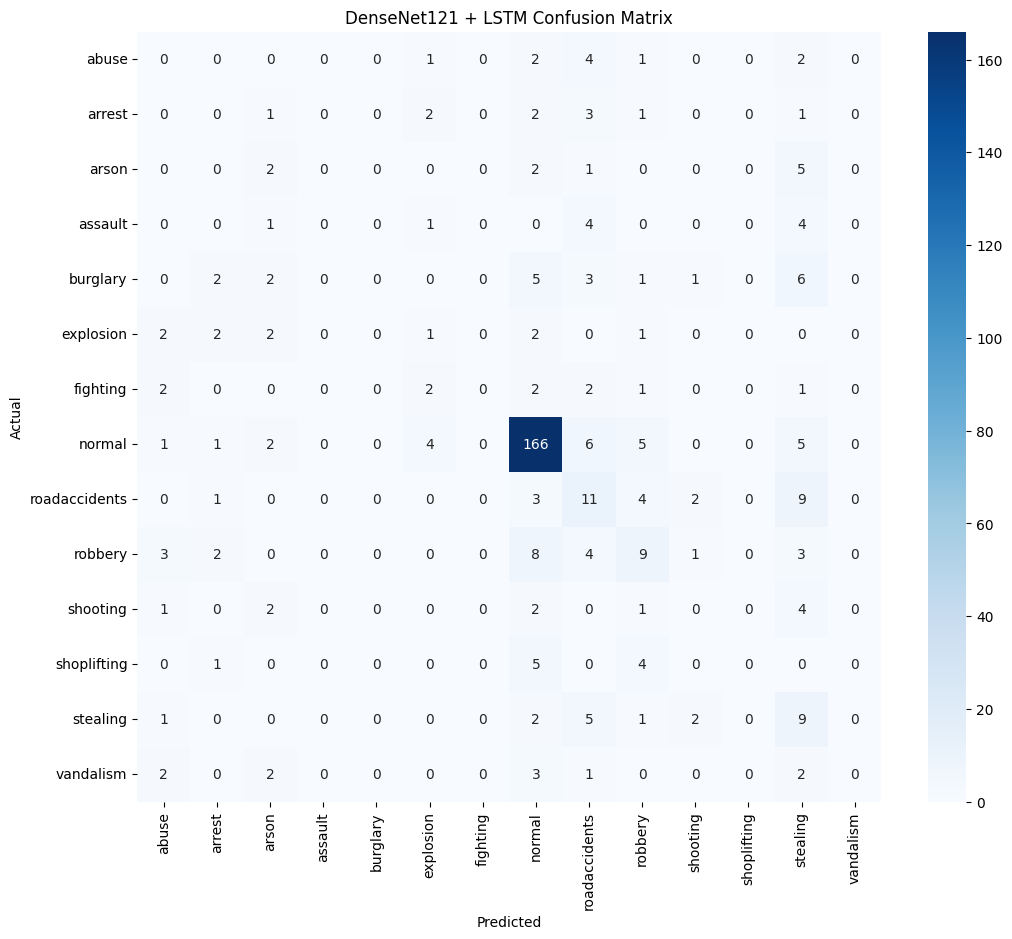

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x,y in val_loader:
        out = model(x.to(DEVICE))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DenseNet121 + LSTM Confusion Matrix")
plt.show()


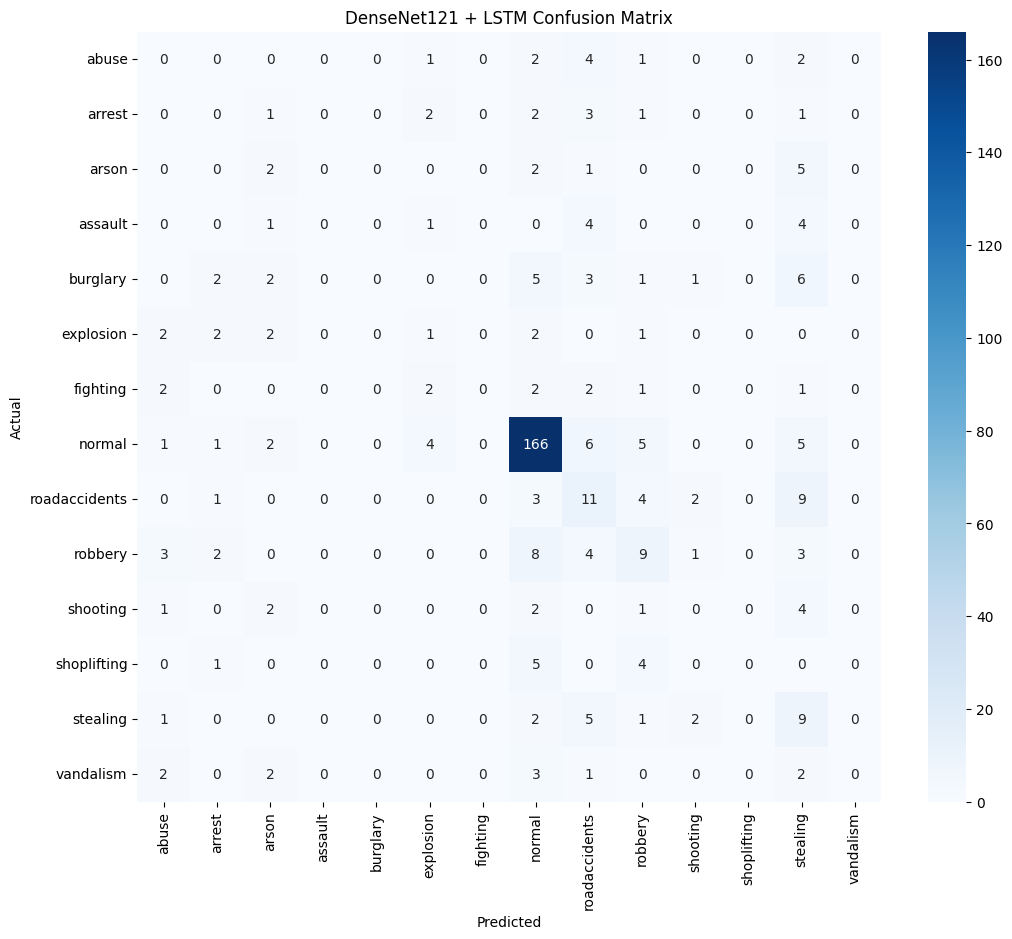

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x,y in val_loader:
        out = model(x.to(DEVICE))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DenseNet121 + LSTM Confusion Matrix")
plt.show()
